In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    trasformation_E_to_X, 
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go


\begin{equation}
    p(\widetilde{X})|d\widetilde{X}| = \eta(\widetilde{\varepsilon})|d\widetilde{\varepsilon}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon})|\frac{d\widetilde{\varepsilon}}{d\widetilde{X}}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon}(\widetilde{X}))\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

Where 


I have a trasformation between bounded and unbounded orbital elements (a,e,i) -> (A,E,I) given by 

\begin{equation}
    A = Ln(\frac{a}{a_{max} - a}) 
\end{equation}

\begin{equation}
    E = Ln(\frac{e}{e_{max} - e}) 
\end{equation}

\begin{equation}
    I = Ln(\frac{i}{i_{max} - i}) 
\end{equation}

please give me the jacobian matriz of this trasformation between bounded (a,e,i) and unbounded (A,E,I) orbital elements

In [4]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Testing Jacobian using q instead of a

In [15]:
a = 0.5
e = 0.1
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
q = a*(1-e)

J = compute_jacobian_XoE(a,e,i,w,Omega,M,mu)

In [16]:
J

array([[-1.22222222e+00, -1.11111111e+00,  1.25333620e-31,
        -6.73555740e-17,  1.02342668e-15,  8.98241160e-16],
       [ 1.49679053e-16,  1.36071867e-16,  1.02342668e-15,
        -5.50000000e-01, -3.36777870e-17, -2.76933677e-17],
       [ 2.27428151e-15,  1.13744923e-15,  6.16297582e-32,
         0.00000000e+00,  5.50000000e-01,  4.52267017e-01],
       [-1.77391654e-14, -6.07629559e-15,  9.84438316e-16,
         4.92219158e-16,  8.03854889e+00,  7.34458692e+00],
       [ 5.46910176e-16,  7.70646157e-16,  8.03854889e+00,
         1.59652489e-14, -9.84438316e-16, -8.99452486e-16],
       [-8.93172099e+00, -1.25856068e+01,  4.92219158e-16,
         0.00000000e+00, -1.59652489e-14, -1.36666294e-14]])

In [17]:
E = [q, e, i, Omega, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE_comp=computeNumericalJacobian(E2X,E,dX,**args)
JXoE_comp

array([[-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 1.49679053e-16,  1.36072035e-16,  2.05339955e-16,
        -5.49999908e-01, -3.36777814e-17, -2.76933643e-17],
       [-1.36952207e-13, -2.72707654e-13,  0.00000000e+00,
         0.00000000e+00,  5.49999908e-01,  4.52266960e-01],
       [-3.58961694e-12, -1.79880252e-12,  9.84438152e-16,
         4.92219076e-16,  8.03854755e+00,  7.34458628e+00],
       [ 5.46911864e-16,  7.70646442e-16,  8.03854755e+00,
         5.20179705e-15, -9.84438152e-16, -8.99452407e-16],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

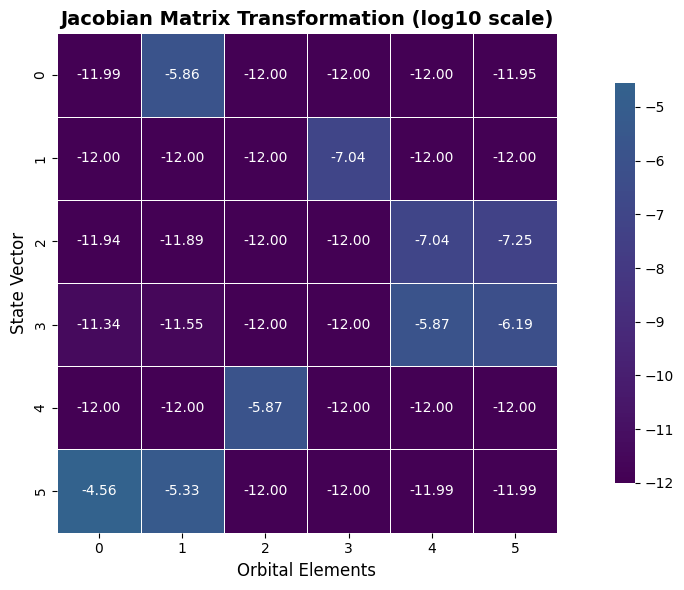

In [18]:
plt.figure(figsize=(12, 6))

# Apply log10 to absolute values, add epsilon to avoid log(0)
eps = 1e-12
data_log = np.log10(np.abs(JXoE_comp - J) + eps)

# Create heatmap
sns.heatmap(data_log, 
            annot=True, 
            fmt='.2f',   # no need for scientific notation, since log scale
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Transformation (log10 scale)', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

### Veryfing CMND fit 

C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


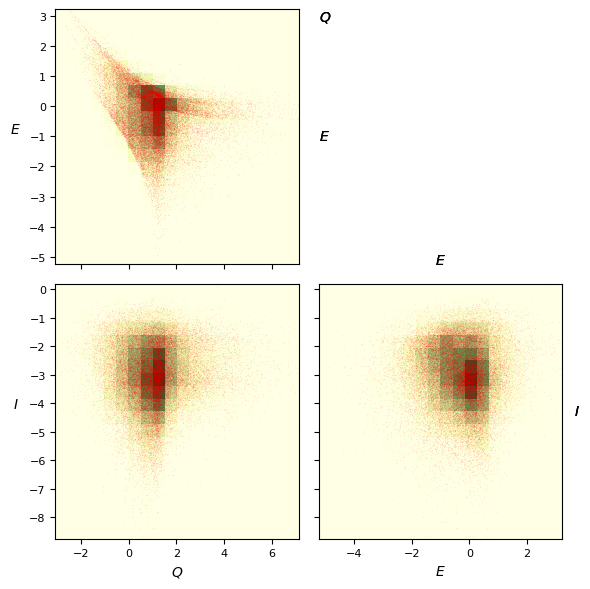

In [5]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [6]:
def P_E_CMND(a: float, e: float, i: float, F: mm.FitCMND) -> float:
    max = 2*np.pi; min = 0

    q = a*(1-e)
    element = np.array([q, e, i])
    scales=[1.35,1.00,np.pi]
    u_element = mm.Util.tIF(element, scales, mm.Util.f2u)

    P_qei = F.cmnd.pdf(u_element)
    P_WwM = 1/(max - min)**3

    return P_qei * P_WwM

In [7]:
def Jacobian_qei_to_QEI(q: float, e: float, i: float, q_max: float, e_max: float, i_max: float) -> np.array:
    partialA_a = q_max/(q*(q_max - q))
    partialA_e = 0
    partialA_i = 0
    partialE_a = 0
    partialE_e = e_max/(e*(e_max - e))
    partialE_i = 0
    partialI_a = 0
    partialI_e = 0
    partialI_i = i_max/(i*(i_max - i))

    Jacobian = np.array([[partialA_a, partialA_e, partialA_i], [partialE_a, partialE_e, partialE_i], [partialI_a, partialI_e, partialI_i]])
    return Jacobian

In [8]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)
        J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            det_QEI = np.linalg.det(J_qei_to_QEI)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det == 0 or not np.isfinite(det):
                print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det 
                #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
                P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                
    return P.reshape(shape)

In [9]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

In [10]:
scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

converted_sample

array([[1.08868334, 0.30860274, 0.62945592],
       [0.93342155, 0.21020885, 0.0556132 ],
       [0.79843816, 0.6171545 , 0.27600827],
       ...,
       [1.09989694, 0.43351821, 0.11763782],
       [0.53539892, 0.82799009, 0.16170043],
       [1.2482112 , 0.49726059, 0.06411522]], shape=(10000000, 3))

In [11]:
N = int(1e7)

q_CMND = converted_sample[:,0]
e_CMND = converted_sample[:,1]
i_CMND = converted_sample[:,2]

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)


elements = np.column_stack((q_CMND, e_CMND, i_CMND, Omega_uniform, w_uniform, M_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_CMND[el]
    e = e_CMND[el]
    i = i_CMND[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]
    a = q/(1-e)

    x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

100%|██████████| 10000000/10000000 [01:44<00:00, 95935.00it/s]


In [21]:
q_max, e_max, i_max = (1.3, 1.0, np.pi)

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_X_CMND(x=X_malla, y=Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_XZ = P_X_CMND(x=X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_VXY = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_VXZ = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)

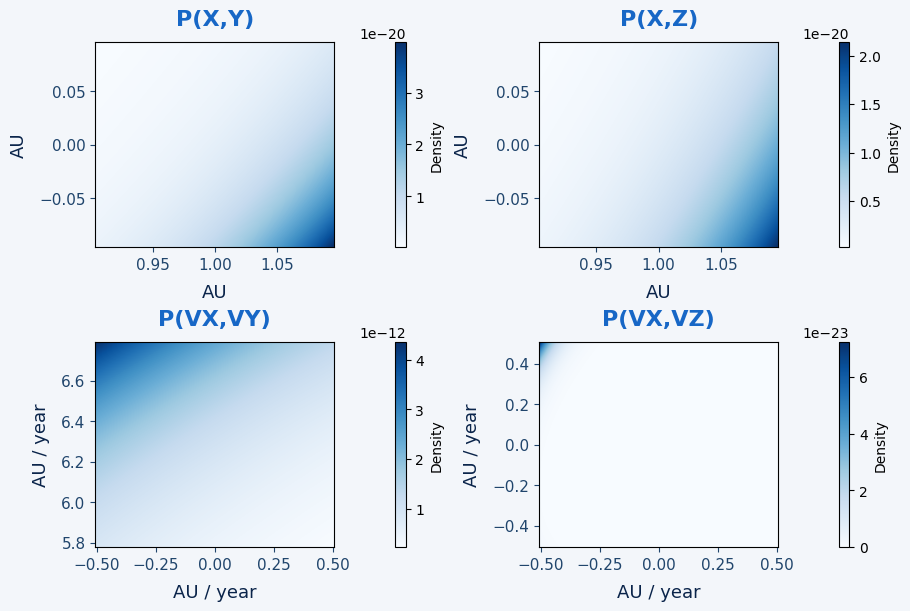

In [22]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [15]:
def surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [28]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
#N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
#print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")

In [32]:
#print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

In [31]:
# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
#print('Ratio', (N_theoretical * N)/N_numeric)

Numerical (count) number of objects inside volume: 1775


In [ ]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')

In [58]:
import sys
import numpy as np
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from utils.Utils import (
    trasformation_X_to_E,
    Jacobian_qei_to_QEI,
    compute_jacobian_XoE,
    P_E_CMND,
    CanonicalUnits,
    GravitationalParameters
    )

deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)
        if q > 1.3 or e > 1: 
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                        print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape), neas_number, not_neas_number

def surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    #print(WF)
    # Evaluate P at all points
    Pf, neas_number, not_neas_number = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)
    #print('Pf: ', Pf)
    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #print('integral: ', integral)
    #return integral, y_points
    return integral, Pf, WF, neas_number, not_neas_number

def surface_integral_P_X_CMND_sphere(center, radius, v_center, v_widths, max_elements, n_points_sphere=6, n_points_vel=6, mu=1, F=mm.FitCMND):
    """
    Hybrid: Integrate P_X_CMND over a position 3-sphere (x, y, z) of center `center[:3]` and radius,
    and (vx, vy, vz) over a box around v_center (with edge lengths v_widths), both with Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, z, vx, vy, vz) center of full 6d space
        radius: float, position space (x,y,z) sphere radius
        v_center: (vx0, vy0, vz0): velocity center
        v_widths: (dvx, dvy, dvz): size of velocity box
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points_sphere: quadrature nodes for radius and angular pos dimensions in positions
        n_points_vel: quadrature nodes per velocity dimension
        mu, F: model params

    Returns:
        Integral (float): estimated integral
        Pf: integrand values at grid points
        WF: effective quadrature weights at points
        neas_number: counter for q>qmax
        not_neas_number: counter for accepted objects
    """
    from numpy.polynomial.legendre import leggauss

    # Position sphere (x,y,z)
    c_x, c_y, c_z = center[:3]
    vx0, vy0, vz0 = v_center
    dvx, dvy, dvz = v_widths
    q_max, e_max, i_max = max_elements

    # Quadrature for radius (0,radius)
    pts_r, wts_r = leggauss(n_points_sphere)
    r_nodes = 0.5 * (pts_r + 1) * radius     # [0, radius]
    r_weights = 0.5 * radius * wts_r

    # Angles for 3-sphere: θ ∈ [0,π], φ ∈ [0,2π]
    pts_theta, wts_theta = leggauss(n_points_sphere)
    theta_nodes = 0.5*(pts_theta + 1)*np.pi    # [0, pi]
    theta_weights = 0.5*np.pi*wts_theta
    factor_theta = np.sin(theta_nodes)         # dΩ = sin θ dθ dφ

    pts_phi, wts_phi = leggauss(n_points_sphere)
    phi_nodes = np.pi*(pts_phi + 1)            # [0, 2pi]
    phi_weights = np.pi*wts_phi

    # Build 3d position grid (r, θ, φ)
    grid_pos = np.meshgrid(r_nodes, theta_nodes, phi_nodes, indexing='ij')
    r_, theta_, phi_ = [g.ravel() for g in grid_pos]
    w_r_, w_theta_, w_phi_ = np.meshgrid(r_weights, theta_weights, phi_weights, indexing='ij')
    f_theta_ = np.sin(theta_)

    # Quadrature for velocity box (vx, vy, vz) - Gauss-Legendre on each side
    pts_v, wts_v = leggauss(n_points_vel)
    vx_nodes = vx0 + 0.5*dvx*pts_v
    vy_nodes = vy0 + 0.5*dvy*pts_v
    vz_nodes = vz0 + 0.5*dvz*pts_v
    vx_weights = 0.5*dvx*wts_v
    vy_weights = 0.5*dvy*wts_v
    vz_weights = 0.5*dvz*wts_v

    # Meshgrid for velocity
    grid_vel = np.meshgrid(vx_nodes, vy_nodes, vz_nodes, indexing='ij')
    vx_, vy_, vz_ = [g.ravel() for g in grid_vel]
    w_vx_, w_vy_, w_vz_ = np.meshgrid(vx_weights, vy_weights, vz_weights, indexing='ij')

    # Now build mesh of all possible combinations (n_pos * n_vel points)
    # For efficiency, use np.broadcast_arrays to align dims, then ravel

    n_pos = r_.size
    n_vel = vx_.size

    # Broadcast all position and velocity arrays to (n_pos * n_vel,)
    X = c_x + r_[:, None]*np.sin(theta_[:, None])*np.cos(phi_[:, None])
    Y = c_y + r_[:, None]*np.sin(theta_[:, None])*np.sin(phi_[:, None])
    Z = c_z + r_[:, None]*np.cos(theta_[:, None])

    # Now tile/repeat X,Y,Z<n_pos*n_vel>, vx,vy,vz<n_pos*n_vel> for all combinations
    X = np.tile(X, (1, n_vel)).ravel()
    Y = np.tile(Y, (1, n_vel)).ravel()
    Z = np.tile(Z, (1, n_vel)).ravel()
    VX = np.tile(vx_, n_pos)
    VY = np.tile(vy_, n_pos)
    VZ = np.tile(vz_, n_pos)

    # Quadrature weights: outer product of position and velocity weights
    W_pos = (w_r_.ravel() * w_theta_.ravel() * f_theta_.ravel() * w_phi_.ravel())
    W_pos = np.tile(W_pos, n_vel)
    W_vel = np.repeat(w_vx_.ravel() * w_vy_.ravel() * w_vz_.ravel(), n_pos)
    WF = W_pos * W_vel

    # Evaluate P_X_CMND at all these points
    Pf, neas_number, not_neas_number = P_X_CMND(
        X, Y, Z, VX, VY, VZ, 
        q_max, e_max, i_max, mu, F=F
    )

    integral = np.sum(Pf * WF)

    return integral

In [55]:
# Numerical: count number of objects in both spatial sphere and velocity volume from the sample

# Parameters for the spatial sphere
c_x = 1
c_y = 0
c_z = 0
rxyz = 0.5  # radius of the position sphere

# Parameters for the velocity volume (cube)
v_x = 0
v_y = (mu/1)**0.5
v_z = 0
dvxyz = 5000 * (1/AU_m) * year  # width of the velocity cube

# Compute boolean mask for objects inside the sphere (position criteria)
dx = state_vectors[:,0] - c_x
dy = state_vectors[:,1] - c_y
dz = state_vectors[:,2] - c_z
distance_to_center = np.sqrt(dx**2 + dy**2 + dz**2)
objs_pos = (distance_to_center <= rxyz)
N_inside_sphere = objs_pos.sum()
print(f'Numerical (count) number of objects inside spatial sphere: {N_inside_sphere}')

# Compute boolean mask for objects inside the velocity volume (velocity criteria)
objs_vx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2)
objs_vy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2)
objs_vz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2)
objs_vel = objs_vx & objs_vy & objs_vz
N_inside_volume = objs_vel.sum()
print(f'Numerical (count) number of objects inside velocity volume: {N_inside_volume}')

# Now count those inside BOTH the spatial sphere AND the velocity volume
objs_both = objs_pos & objs_vel
N_inside_both = objs_both.sum()
print(f'Numerical (count) number of objects inside sphere AND velocity volume: {N_inside_both}')

center = (c_x, c_y, c_z)
radius = rxyz
v_center = (v_x, v_y, v_z)
v_widths = (dvxyz, dvxyz, dvxyz)
integral_result = surface_integral_P_X_CMND_sphere(center, radius, v_center, v_widths, max_elements, n_points_sphere=6, n_points_vel=6, mu=mu, F=F)
print('Number of objects theorically: ', integral_result * N)

Numerical (count) number of objects inside spatial sphere: 428220
Numerical (count) number of objects inside velocity volume: 20358
Numerical (count) number of objects inside sphere AND velocity volume: 14068
Number of objects theorically:  741210.631166716


In [60]:
# ---------------------------------------------------------
# 1. Setup Parameters
# ---------------------------------------------------------
# Position Sphere Parameters
c_x, c_y, c_z = 1.0, 0.0, 0.0
center_pos = np.array([c_x, c_y, c_z])
rxyz = 0.5   # Radius of the position sphere

# Velocity Box Parameters
v_x, v_y, v_z = 0.0, (mu/1)**0.5, 0.0
center_vel = np.array([v_x, v_y, v_z])
dvxyz = 5000 * (1/AU_m) * year  # Velocity box HALF-width

# Integration settings
degree = 6 
max_elements = (1.3, 1.0, np.pi) # q_max, e_max, i_max

# ---------------------------------------------------------
# 2. Theoretical: Compute Surface Integral
# ---------------------------------------------------------
# This calculates the probability mass inside the volume
integral_result = surface_integral_P_X_CMND_sphere(center_pos, rxyz, center_vel, v_widths, max_elements, n_points_sphere=6, n_points_vel=6, mu=mu, F=F)

# If P_X_CMND is a PDF, Expected Count = Integral * Total_Samples
# If P_X_CMND is a number density, Expected Count = Integral
total_samples = len(state_vectors)
N_theoretical = integral_result * total_samples

print(f"Integral Result (Probability): {integral_result:.6e}")
print(f"Theoretical Number of objects: {N_theoretical:.2f}")

# ---------------------------------------------------------
# 3. Numerical: Count Samples in Hybrid Volume
# ---------------------------------------------------------

# A. Position Filter: SPHERE
# Calculate squared Euclidean distance from center (c_x, c_y, c_z)
dx = state_vectors[:, 0] - c_x
dy = state_vectors[:, 1] - c_y
dz = state_vectors[:, 2] - c_z
dist_sq = dx**2 + dy**2 + dz**2

# Check if distance <= radius
objs_pos_sphere = (dist_sq <= rxyz**2)

# B. Velocity Filter: BOX (Cube)
# Check if absolute difference is less than HALF-width (dvxyz) for each component
# Note: In the integration function, 'dv' was used as [v-dv, v+dv]
objs_vx = (np.abs(state_vectors[:, 3] - v_x) <= dvxyz)
objs_vy = (np.abs(state_vectors[:, 4] - v_y) <= dvxyz)
objs_vz = (np.abs(state_vectors[:, 5] - v_z) <= dvxyz)
objs_vel_box = objs_vx & objs_vy & objs_vz

# C. Combine Filters
objects_in_volume = objs_pos_sphere & objs_vel_box
N_numeric = objects_in_volume.sum()

print(f"Numerical (count) number of objects: {N_numeric}")

# ---------------------------------------------------------
# 4. Validation Metric
# ---------------------------------------------------------
if N_numeric > 0:
    diff = abs(N_theoretical - N_numeric)
    pct_error = (diff / N_numeric) * 100
    print(f"Difference: {diff:.2f}")
    print(f"Percent Error: {pct_error:.2f}%")
else:
    print("Zero objects found in numerical sample.")

Integral Result (Probability): 7.412106e-02
Theoretical Number of objects: 741210.63
Numerical (count) number of objects: 73646
Difference: 667564.63
Percent Error: 906.45%


In [50]:
import numpy as np
from numpy.polynomial.legendre import leggauss

def calculate_surface_integral_P_X_CMND(
    c: np.array,
    r: float,
    v: np.array,
    dv: float,
    deg: int,
    q_max: float,
    e_max: float,
    i_max: float,
    mu: float,
    F: object
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    vx_vals = v[0] + dv * nodes
    vy_vals = v[1] + dv * nodes
    vz_vals = v[2] + dv * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, Vx, Vy, Vz = np.meshgrid(
        rho_vals, theta_vals, phi_vals, vx_vals, vy_vals, vz_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_vx, W_vy, W_vz = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    X = c[0] + Rho * sin_theta * cos_phi
    Y = c[1] + Rho * sin_theta * sin_phi
    Z = c[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r / 2.0) * (np.pi / 2.0) * np.pi * (dv**3)
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_vx * W_vy * W_vz 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(
        X.ravel(), Y.ravel(), Z.ravel(), 
        Vx.ravel(), Vy.ravel(), Vz.ravel(),
        q_max, e_max, i_max, mu, F
    )
    
    # --- FIX FOR TUPLE RETURN ---
    # If P_X_CMND returns (P, neas_count, etc.), take the first element.
    if isinstance(P_output, tuple):
        P_flat = P_output[0]
    else:
        P_flat = P_output
        
    # Ensure it is a numpy array
    P_flat = np.asarray(P_flat)
    # ----------------------------

    # 8. Integrate
    # Reshape P_flat to match the 6D grid shape of total_weights
    try:
        P_grid = P_flat.reshape(total_weights.shape)
    except ValueError as e:
        print(f"Shape Error Details: P_flat size {P_flat.size}, Weights shape {total_weights.shape}")
        raise e
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.nansum(weighted_values)
    
    return integral_result

In [54]:
N = int(1e7)
# Parameters for the spatial sphere
c_x = 1
c_y = 0
c_z = 0
rxyz = 0.5  # radius of the position sphere

# Parameters for the velocity volume (cube)
v_x = 0
v_y = (mu/1)**0.5
v_z = 0
dvxyz = 5000 * (1/AU_m) * year  # width of the velocity cube

# Compute boolean mask for objects inside the sphere (position criteria)
dx = state_vectors[:,0] - c_x
dy = state_vectors[:,1] - c_y
dz = state_vectors[:,2] - c_z
distance_to_center = np.sqrt(dx**2 + dy**2 + dz**2)
objs_pos = (distance_to_center <= rxyz)
N_inside_sphere = objs_pos.sum()
print(f'Numerical (count) number of objects inside spatial sphere: {N_inside_sphere}')

# Compute boolean mask for objects inside the velocity volume (velocity criteria)
objs_vx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2)
objs_vy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2)
objs_vz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2)
objs_vel = objs_vx & objs_vy & objs_vz
N_inside_volume = objs_vel.sum()
print(f'Numerical (count) number of objects inside velocity volume: {N_inside_volume}')

# Now count those inside BOTH the spatial sphere AND the velocity volume
objs_both = objs_pos & objs_vel
N_inside_both = objs_both.sum()
print(f'Numerical (count) number of objects inside sphere AND velocity volume: {N_inside_both}')
# Assumes you have your 'F' object and necessary constants
center_pos = np.array([c_x, c_y, c_z]) # Example 1 AU
radius_pos = rxyz                       # Sphere radius
center_vel = np.array([v_x, v_y, v_z]) # Example velocity
dv_vel = dvxyz                          # Velocity box half-width
degree = 6                             # 6 points per dim = 46,656 evals

result = calculate_surface_integral_P_X_CMND(
    center_pos, radius_pos, 
    center_vel, dv_vel, 
    degree, 
    q_max=1.3, e_max=1.0, i_max=np.pi, mu=mu, F=F
)

print("Integral Result:", result)
print('Number of objects theorically: ', result * N)

Numerical (count) number of objects inside spatial sphere: 428220
Numerical (count) number of objects inside velocity volume: 20358
Numerical (count) number of objects inside sphere AND velocity volume: 14068
Integral Result: 0.008053866946509461
Number of objects theorically:  80538.66946509462


In [12]:
def P_X_CMND_estesi(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)
        if q > 1.3 or e > 1: 
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                        print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape)

def calculate_surface_integral_P_X_CMND_estesi(
    c: np.array,
    r: float,
    v: np.array,
    dv: float,
    deg: int,
    q_max: float,
    e_max: float,
    i_max: float,
    mu: float,
    F: object
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    vx_vals = v[0] + dv * nodes
    vy_vals = v[1] + dv * nodes
    vz_vals = v[2] + dv * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, Vx, Vy, Vz = np.meshgrid(
        rho_vals, theta_vals, phi_vals, vx_vals, vy_vals, vz_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_vx, W_vy, W_vz = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    X = c[0] + Rho * sin_theta * cos_phi
    Y = c[1] + Rho * sin_theta * sin_phi
    Z = c[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r / 2.0) * (np.pi / 2.0) * np.pi * (dv**3)
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_vx * W_vy * W_vz 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND_estesi(
        X.ravel(), Y.ravel(), Z.ravel(), 
        Vx.ravel(), Vy.ravel(), Vz.ravel(),
        q_max, e_max, i_max, mu, F
    )
    
    # --- FIX FOR TUPLE RETURN ---
    # If P_X_CMND returns (P, neas_count, etc.), take the first element.
    if isinstance(P_output, tuple):
        P_flat = P_output[0]
    else:
        P_flat = P_output
        
    # Ensure it is a numpy array
    P_flat = np.asarray(P_flat)
    # ----------------------------

    # 8. Integrate
    # Reshape P_flat to match the 6D grid shape of total_weights
    try:
        P_grid = P_flat.reshape(total_weights.shape)
    except ValueError as e:
        print(f"Shape Error Details: P_flat size {P_flat.size}, Weights shape {total_weights.shape}")
        raise e
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.nansum(weighted_values)
    
    return integral_result

In [13]:
# ---------------------------------------------------------
# 1. Setup Parameters
# ---------------------------------------------------------
# Position Sphere Parameters
c_x, c_y, c_z = 1.0, 0.0, 0.0
center_pos = np.array([c_x, c_y, c_z])
rxyz = 0.5   # Radius of the position sphere

# Velocity Box Parameters
v_x, v_y, v_z = 0.0, (mu/1)**0.5, 0.0
center_vel = np.array([v_x, v_y, v_z])
dvxyz = 5000 * (1/AU_m) * year  # Velocity box HALF-width

# Integration settings
degree = 6 
max_elements = (1.3, 1.0, np.pi) # q_max, e_max, i_max

# ---------------------------------------------------------
# 3. Numerical: Count Samples in Hybrid Volume
# ---------------------------------------------------------

# A. Position Filter: SPHERE
# Calculate squared Euclidean distance from center (c_x, c_y, c_z)
dx = state_vectors[:, 0] - c_x
dy = state_vectors[:, 1] - c_y
dz = state_vectors[:, 2] - c_z
dist_sq = dx**2 + dy**2 + dz**2

# Check if distance <= radius
objs_pos_sphere = (dist_sq <= rxyz**2)

# B. Velocity Filter: BOX (Cube)
# Check if absolute difference is less than HALF-width (dvxyz) for each component
# Note: In the integration function, 'dv' was used as [v-dv, v+dv]
objs_vx = (np.abs(state_vectors[:, 3] - v_x) <= dvxyz)
objs_vy = (np.abs(state_vectors[:, 4] - v_y) <= dvxyz)
objs_vz = (np.abs(state_vectors[:, 5] - v_z) <= dvxyz)
objs_vel_box = objs_vx & objs_vy & objs_vz

# C. Combine Filters
objects_in_volume = objs_pos_sphere & objs_vel_box
N_numeric = objects_in_volume.sum()

print(f"Numerical (count) number of objects: {N_numeric}")

result = calculate_surface_integral_P_X_CMND_estesi(
    center_pos, rxyz, 
    center_vel, dvxyz, 
    degree, 
    q_max=1.3, e_max=1.0, i_max=np.pi, mu=mu, F=F
)

print("Integral Result:", result)
print('Number of objects theorically: ', result * N)

Numerical (count) number of objects: 73733
Integral Result: 0.008053866946509461
Number of objects theorically:  80538.66946509462


In [14]:
print('Ratio', (result * N)/N_numeric)

Ratio 1.0923015402207237
